# Day 2 Notebook — Gradient Calibration, Geometric Distortion, and Eddy-Current Mitigation

In Day 1, we used gradients to move through k-space and create 1D and 2D spin-echo measurements.

Today, we ask what happens when those gradients are imperfect.

This notebook has two sections:

1. **Geometric distortion correction**
   - What happens when the gradient scale or gradient field is wrong?
   - How can we estimate and correct image geometry?

2. **Eddy-current mitigation**
   - What happens when gradient errors change with time?
   - How can we design a simple experiment to measure and reduce them?

The workshop rhythm is:

```text
Learn → Design → Build → Scan
```

The key message is:

```text
Gradients define image geometry.
```


In [4]:
# Shared setup for Day 2

import numpy as np
import matplotlib.pyplot as plt

print("DELTA DIY MRI Day 2 notebook")
print("----------------------------")
print("Topic: gradient calibration, geometric distortion, and eddy-current mitigation")

# Scanner / imaging constants used across the notebook
B0_T = 0.2516
gamma_hz_per_t = 42.576e6
f0_hz = gamma_hz_per_t * B0_T

# Default image grid
nx = 64
ny = 64
fov_x_m = 0.064
fov_y_m = 0.064

dx_m = fov_x_m / nx
dy_m = fov_y_m / ny

print()
print(f"B0 field strength : {B0_T:.4f} T")
print(f"Larmor frequency  : {f0_hz/1e6:.3f} MHz")
print(f"Matrix            : {nx} × {ny}")
print(f"FOV               : {fov_x_m*1e3:.1f} × {fov_y_m*1e3:.1f} mm")
print(f"Voxel size        : {dx_m*1e3:.2f} × {dy_m*1e3:.2f} mm")


DELTA DIY MRI Day 2 notebook
----------------------------
Topic: gradient calibration, geometric distortion, and eddy-current mitigation

B0 field strength : 0.2516 T
Larmor frequency  : 10.712 MHz
Matrix            : 64 × 64
FOV               : 64.0 × 64.0 mm
Voxel size        : 1.00 × 1.00 mm


---

# Section I — Geometric Distortion Correction

## Learn: gradient calibration enters reconstruction

The gradient team measures the hardware relationship:

$G_x = S_x I_x$

where:

- $I_x$ is the gradient amplifier current,
- $S_x$ is the gradient calibration constant,
- $G_x$ is the gradient strength.

The reconstruction assumes that the commanded gradient produces the intended k-space trajectory:

$k_x(t) = \gamma \int_0^t G_x(\tau)\,d\tau$

If the gradient scale is wrong, the reconstructed image has the wrong geometry.

A simple example:

- If the actual gradient is weaker than expected, k-space is traversed less than intended.
- The reconstructed FOV becomes wrong.
- Objects can appear stretched or compressed.

So geometric distortion correction starts with a simple question:

> Do known distances in the image match known distances in the object?


## Design: work it by hand

Suppose the 2D SE notebook is designed for:

- $FOV_x = 64$ mm
- $N_x = 64$
- nominal voxel size $= 64/64 = 1$ mm

A dot phantom has two dots that are truly separated by:

$d_{true} = 40 \text{ mm}$

But in the image, the measured distance is:

$d_{meas} = 42 \text{ mm}$

The image is stretched by:

$c_x = \frac{d_{meas}}{d_{true}} = \frac{42}{40} = 1.05$

So the coordinate correction is:

$x_{corrected} = \frac{x_{measured}}{c_x}$

Interpretation:

- the image is 5% too large along x,
- the gradient scale used in reconstruction is effectively 5% off,
- corrected distances should be divided by 1.05.


In [9]:
# Design: numerical gradient-scale correction problem

print("Geometric distortion numerical example")
print("--------------------------------------")

FOVx_mm = 64
nx = 64
voxel_size_mm = FOVx_mm / nx

d_true_mm = 40
d_meas_mm = 42

cx = d_meas_mm / d_true_mm
d_corrected_mm = d_meas_mm / cx

print(f"FOVx                 : {FOVx_mm:.1f} mm")
print(f"Matrix nx            : {nx}")
print(f"Nominal voxel size   : {voxel_size_mm:.2f} mm")
print()
print(f"True dot separation  : {d_true_mm:.1f} mm")
print(f"Measured separation  : {d_meas_mm:.1f} mm")
print(f"Scale factor cx      : {cx:.4f}")
print(f"Percent stretch      : {(cx - 1)*100:.1f}%")
print(f"Corrected distance   : {d_corrected_mm:.1f} mm")


Geometric distortion numerical example
--------------------------------------
FOVx                 : 64.0 mm
Matrix nx            : 64
Nominal voxel size   : 1.00 mm

True dot separation  : 40.0 mm
Measured separation  : 42.0 mm
Scale factor cx      : 1.0500
Percent stretch      : 5.0%
Corrected distance   : 40.0 mm


## Build: simulate a dot phantom

For this notebook, a dot phantom is useful because each dot has a known location.

A dot phantom lets us estimate:

$x_{meas} = c_x x_{true}$

and then correct:

$x_{corrected} = \frac{x_{meas}}{c_x}$

Later, this same idea can extend to spatially varying distortion:

$x_{meas} = x_{true} + D_x(x,y)$

where $D_x(x,y)$ is a displacement field.


Create ideal dot phantom
------------------------


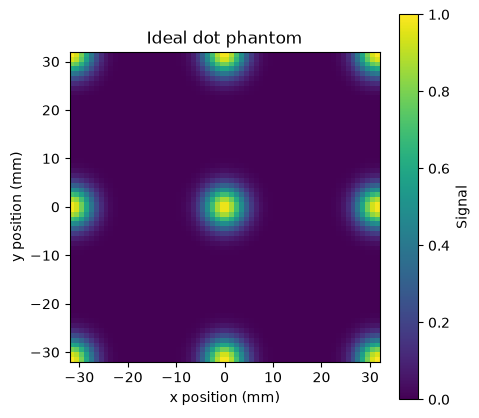

Number of dots: 9
Dot spacing   : 16.0 mm


In [10]:
# Build: create an ideal dot phantom

print("Create ideal dot phantom")
print("------------------------")

# Coordinate grid in mm
x_mm = np.linspace(-fov_x_m*1e3/2, fov_x_m*1e3/2, nx)
y_mm = np.linspace(-fov_y_m*1e3/2, fov_y_m*1e3/2, ny)
X_mm, Y_mm = np.meshgrid(x_mm, y_mm, indexing="xy")

# Define known dot centers in mm
dot_spacing_mm = 16
dot_centers = []

for x0 in [-32, 0, 32]:
    for y0 in [-32, 0, 32]:
        dot_centers.append((x0, y0))

dot_sigma_mm = 3.0

phantom = np.zeros((ny, nx), dtype=float)

for x0, y0 in dot_centers:
    phantom += np.exp(-0.5 * (((X_mm - x0) / dot_sigma_mm) ** 2 + ((Y_mm - y0) / dot_sigma_mm) ** 2))

phantom = phantom / np.max(phantom)

plt.figure(figsize=(5, 5))
plt.imshow(
    phantom,
    extent=[x_mm[0], x_mm[-1], y_mm[0], y_mm[-1]],
    origin="lower",
    vmin=0,
    vmax=1,
)
plt.title("Ideal dot phantom")
plt.xlabel("x position (mm)")
plt.ylabel("y position (mm)")
plt.colorbar(label="Signal")
plt.show()

print(f"Number of dots: {len(dot_centers)}")
print(f"Dot spacing   : {dot_spacing_mm:.1f} mm")


Simulate gradient-scale distortion
----------------------------------


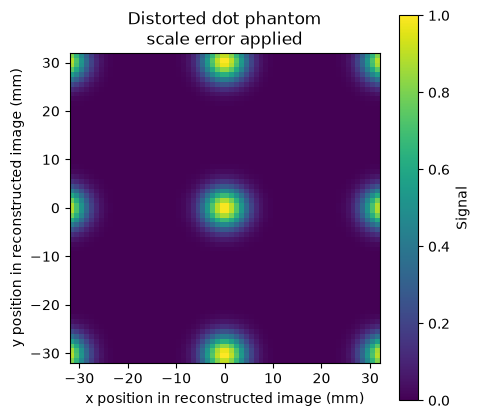

True simulated distortion:
  cx = 1.050  (+5.0% x scale)
  cy = 0.960  (-4.0% y scale)


In [11]:
# Build: simulate geometric distortion from gradient scale error

print("Simulate gradient-scale distortion")
print("----------------------------------")

# Example scale errors
cx_true = 1.05   # x appears 5% stretched
cy_true = 0.96   # y appears 4% compressed

# Distorted coordinate model:
# The image appears as if object coordinates were scaled.
X_distorted_mm = X_mm / cx_true
Y_distorted_mm = Y_mm / cy_true

distorted = np.zeros_like(phantom)

for x0, y0 in dot_centers:
    distorted += np.exp(
        -0.5 * (
            ((X_distorted_mm - x0) / dot_sigma_mm) ** 2
            + ((Y_distorted_mm - y0) / dot_sigma_mm) ** 2
        )
    )

distorted = distorted / np.max(distorted)

plt.figure(figsize=(5, 5))
plt.imshow(
    distorted,
    extent=[x_mm[0], x_mm[-1], y_mm[0], y_mm[-1]],
    origin="lower",
    vmin=0,
    vmax=1,
)
plt.title("Distorted dot phantom\nscale error applied")
plt.xlabel("x position in reconstructed image (mm)")
plt.ylabel("y position in reconstructed image (mm)")
plt.colorbar(label="Signal")
plt.show()

print("True simulated distortion:")
print(f"  cx = {cx_true:.3f}  ({(cx_true-1)*100:+.1f}% x scale)")
print(f"  cy = {cy_true:.3f}  ({(cy_true-1)*100:+.1f}% y scale)")


## Build assignment: estimate the scale correction

Your task:

1. Use the distorted dot phantom.
2. Pick the left and right dots along the center row.
3. Measure their apparent separation.
4. Compare with the known true separation.
5. Estimate $c_x$.
6. Correct the measured x-coordinates.

Suggested output:

- measured dot separation,
- estimated $c_x$,
- corrected distance,
- before/after image or coordinate plot.


In [12]:
# Helper: estimate scale factor from known dot positions

print("Estimate scale factor from dot spacing")
print("--------------------------------------")

# For this first tutorial version, we use the known simulated scale.
# Students can replace this with centroid detection later.

true_left_x_mm = -16
true_right_x_mm = 16
true_separation_x_mm = true_right_x_mm - true_left_x_mm

measured_left_x_mm = cx_true * true_left_x_mm
measured_right_x_mm = cx_true * true_right_x_mm
measured_separation_x_mm = measured_right_x_mm - measured_left_x_mm

cx_est = measured_separation_x_mm / true_separation_x_mm

print(f"True separation x      : {true_separation_x_mm:.1f} mm")
print(f"Measured separation x  : {measured_separation_x_mm:.1f} mm")
print(f"Estimated cx           : {cx_est:.4f}")
print(f"Estimated x distortion : {(cx_est - 1)*100:+.1f}%")

# Correct distorted x positions
x_meas_example = np.array([-16, 0, 16])
x_corr_example = x_meas_example / cx_est

print()
print("Example correction:")
for xm, xc in zip(x_meas_example, x_corr_example):
    print(f"  x_measured = {xm:6.1f} mm  →  x_corrected = {xc:6.1f} mm")


Estimate scale factor from dot spacing
--------------------------------------
True separation x      : 32.0 mm
Measured separation x  : 33.6 mm
Estimated cx           : 1.0500
Estimated x distortion : +5.0%

Example correction:
  x_measured =  -16.0 mm  →  x_corrected =  -15.2 mm
  x_measured =    0.0 mm  →  x_corrected =    0.0 mm
  x_measured =   16.0 mm  →  x_corrected =   15.2 mm


Visualize coordinate correction
-------------------------------


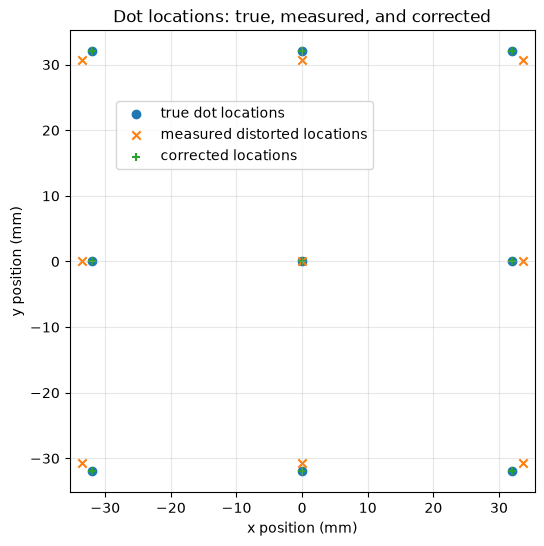

In [20]:
# Build: visualize before/after coordinate correction

print("Visualize coordinate correction")
print("-------------------------------")

true_points = np.array(dot_centers)
measured_points = true_points.copy().astype(float)
measured_points[:, 0] *= cx_true
measured_points[:, 1] *= cy_true

corrected_points = measured_points.copy()
corrected_points[:, 0] /= cx_est
corrected_points[:, 1] /= cy_true  # in a real scan, estimate cy from vertical dot spacing

plt.figure(figsize=(6, 6))
plt.scatter(true_points[:, 0], true_points[:, 1], marker="o", label="true dot locations")
plt.scatter(measured_points[:, 0], measured_points[:, 1], marker="x", label="measured distorted locations")
plt.scatter(corrected_points[:, 0], corrected_points[:, 1], marker="+", label="corrected locations")
plt.xlabel("x position (mm)")
plt.ylabel("y position (mm)")
plt.title("Dot locations: true, measured, and corrected")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend(loc=(0.1, 0.7), fontsize=10)
plt.show()


## Scan: what to acquire on the scanner

For the scan-facing part, use the **2D spin echo sequence** from the Day 1 / Day 2 imaging notebook.

Recommended scan target:

- dot-array phantom, preferred, or
- grid phantom, acceptable.

For geometric distortion correction, dots are preferred because their centroids can be measured automatically.

Suggested acquisition:

```text
Sequence: 2D SE
Object: dot-array phantom or grid phantom
FOV: 64 mm × 64 mm
Matrix: 64 × 64
TE: short feasible TE
TR: 1000 ms or scanner-safe value
Ordering: inside-out or linear; either is acceptable for geometry
Output: reconstructed image + measured dot positions
```

Ask the phantom team for:

- known dot spacing,
- dot diameter,
- dot layout,
- physical orientation marker,
- expected FOV coverage,
- photograph or CAD drawing of the phantom.

Notebook scan deliverable:

1. acquire the 2D SE image,
2. measure apparent dot spacing,
3. estimate $c_x$ and $c_y$,
4. report corrected geometry.


---

# Section II — Eddy-Current Mitigation

## Learn: eddy currents are time-dependent gradient errors

A static gradient scale error asks:

> Did the gradient have the right amplitude?

An eddy-current error asks:

> Did the gradient have the right amplitude at the right time?

When a gradient changes rapidly, nearby conductive structures can experience induced currents. Those currents generate their own magnetic fields. In MRI, this residual field can persist after the commanded gradient lobe is over.

A simple model is:

$G_{actual}(t) = G_{commanded}(t) + G_{eddy}(t)$

with:

$G_{eddy}(t) = \alpha G_0 e^{-t/\tau}$

where:

- $\alpha$ is the residual-field amplitude relative to the applied lobe,
- $\tau$ is the eddy-current decay time,
- $G_0$ is the applied perturbation gradient amplitude.


## Design: work it by hand

Suppose an eddy-current measurement gives:

$\tau = 2 \text{ ms}$

and:

$\alpha = 0.08$

The residual term after delay $\Delta t$ is:

$\frac{G_{eddy}(\Delta t)}{G_{eddy}(0)} = e^{-\Delta t/\tau}$

At $\Delta t = \tau = 2$ ms:

$e^{-1} \approx 0.37$

At $\Delta t = 3\tau = 6$ ms:

$e^{-3} \approx 0.05$

Interpretation:

- after 2 ms, about 37% of the residual effect remains,
- after 6 ms, about 5% remains,
- if TE/SNR allows, waiting a few milliseconds may be enough,
- if TE is tight, use compensation or reconstruction correction.


Eddy-current decay numerical example
------------------------------------
tau   : 2.0 ms
alpha : 0.080

Delay Δt | relative residual | residual as fraction of G0
---------|-------------------|---------------------------
    0.0 ms |             1.000 |                    0.0800
    1.0 ms |             0.607 |                    0.0485
    2.0 ms |             0.368 |                    0.0294
    4.0 ms |             0.135 |                    0.0108
    6.0 ms |             0.050 |                    0.0040
    8.0 ms |             0.018 |                    0.0015
   10.0 ms |             0.007 |                    0.0005


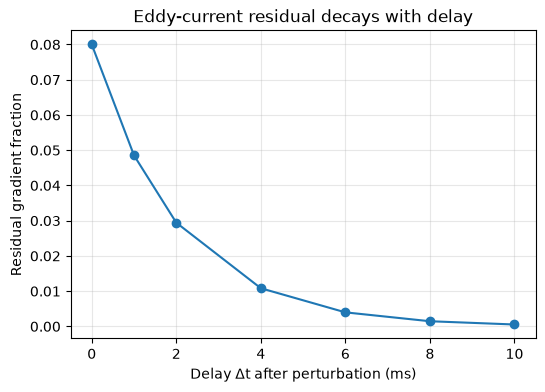

In [21]:
# Design: eddy-current decay numerical example

print("Eddy-current decay numerical example")
print("------------------------------------")

tau_ms = 2.0
alpha = 0.08

delta_t_ms = np.array([0, 1, 2, 4, 6, 8, 10], dtype=float)
relative_residual = np.exp(-delta_t_ms / tau_ms)
absolute_residual = alpha * relative_residual

print(f"tau   : {tau_ms:.1f} ms")
print(f"alpha : {alpha:.3f}")
print()
print("Delay Δt | relative residual | residual as fraction of G0")
print("---------|-------------------|---------------------------")

for dt, rr, ar in zip(delta_t_ms, relative_residual, absolute_residual):
    print(f"{dt:7.1f} ms | {rr:17.3f} | {ar:25.4f}")

plt.figure(figsize=(6, 4))
plt.plot(delta_t_ms, absolute_residual, marker="o")
plt.xlabel("Delay Δt after perturbation (ms)")
plt.ylabel("Residual gradient fraction")
plt.title("Eddy-current residual decays with delay")
plt.grid(True, alpha=0.3)
plt.show()


## Build: simulate how eddy currents shift a projection

In the proposed assignment, we keep the imaging sequence fixed:

```text
90°x → Gx,pre → 180°y → Gx readout + ADC
```

Then we add one controlled perturbation lobe before the acquisition and vary only $\Delta t$.

If the residual eddy field is still present during readout, the measured projection can shift or acquire a phase ramp.

For this tutorial, we simulate the simplest measurable effect:

$\Delta x(\Delta t) = A e^{-\Delta t/\tau}$

where $\Delta x$ is the projection shift.


Simulate eddy-current projection shifts
---------------------------------------


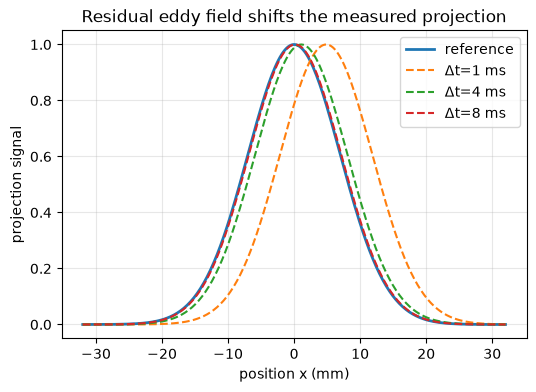

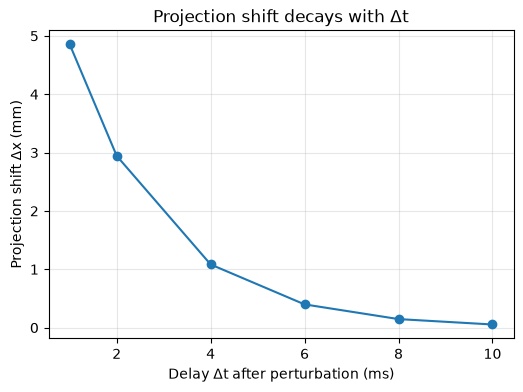

True simulation parameters:
  A   = 8.00 mm
  tau = 2.00 ms


In [22]:
# Build: simulate projection shift versus perturb-to-readout delay

print("Simulate eddy-current projection shifts")
print("---------------------------------------")

# Position axis for 1D projection
x_proj_mm = np.linspace(-32, 32, 256)

# Reference projection
sigma_mm = 7.0
projection_ref = np.exp(-0.5 * (x_proj_mm / sigma_mm) ** 2)

# Eddy-current shift model
tau_true_ms = 2.0
A_true_mm = 8.0

delta_t_ms = np.array([1, 2, 4, 6, 8, 10], dtype=float)
shift_mm = A_true_mm * np.exp(-delta_t_ms / tau_true_ms)

plt.figure(figsize=(6, 4))

plt.plot(x_proj_mm, projection_ref, linewidth=2, label="reference")

for dt, shift in zip(delta_t_ms[[0, 2, 4]], shift_mm[[0, 2, 4]]):
    projection_shifted = np.exp(-0.5 * ((x_proj_mm - shift) / sigma_mm) ** 2)
    plt.plot(x_proj_mm, projection_shifted, linestyle="--", label=f"Δt={dt:.0f} ms")

plt.xlabel("position x (mm)")
plt.ylabel("projection signal")
plt.title("Residual eddy field shifts the measured projection")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(delta_t_ms, shift_mm, marker="o")
plt.xlabel("Delay Δt after perturbation (ms)")
plt.ylabel("Projection shift Δx (mm)")
plt.title("Projection shift decays with Δt")
plt.grid(True, alpha=0.3)
plt.show()

print("True simulation parameters:")
print(f"  A   = {A_true_mm:.2f} mm")
print(f"  tau = {tau_true_ms:.2f} ms")


## Build assignment: fit the eddy-current decay

Your task:

1. Use the simulated projection shifts.
2. Add a small amount of measurement noise.
3. Fit the model:

$\Delta x(\Delta t) = A e^{-\Delta t/\tau}$

4. Estimate $A$ and $\tau$.
5. Decide whether waiting is sufficient or whether compensation/reconstruction correction is needed.


Fit eddy-current decay model
----------------------------


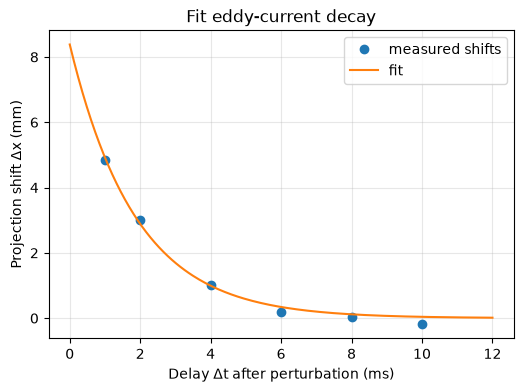

True A      : 8.00 mm
Fitted A    : 8.38 mm

True tau    : 2.00 ms
Fitted tau  : 1.88 ms


In [23]:
# Helper: fit simulated eddy-current projection shift

from scipy.optimize import curve_fit

print("Fit eddy-current decay model")
print("----------------------------")

rng = np.random.default_rng(7)
noise_mm = 0.25 * rng.normal(size=shift_mm.shape)
shift_measured_mm = shift_mm + noise_mm

def exp_decay_model(dt_ms, A_mm, tau_ms):
    return A_mm * np.exp(-dt_ms / tau_ms)

popt, pcov = curve_fit(
    exp_decay_model,
    delta_t_ms,
    shift_measured_mm,
    p0=[6.0, 2.0],
    bounds=([0.0, 0.1], [50.0, 20.0]),
)

A_fit_mm, tau_fit_ms = popt

delta_t_fit = np.linspace(0, 12, 200)
shift_fit = exp_decay_model(delta_t_fit, A_fit_mm, tau_fit_ms)

plt.figure(figsize=(6, 4))
plt.plot(delta_t_ms, shift_measured_mm, "o", label="measured shifts")
plt.plot(delta_t_fit, shift_fit, label="fit")
plt.xlabel("Delay Δt after perturbation (ms)")
plt.ylabel("Projection shift Δx (mm)")
plt.title("Fit eddy-current decay")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"True A      : {A_true_mm:.2f} mm")
print(f"Fitted A    : {A_fit_mm:.2f} mm")
print()
print(f"True tau    : {tau_true_ms:.2f} ms")
print(f"Fitted tau  : {tau_fit_ms:.2f} ms")


## Build: choose a mitigation strategy

The fit gives us two useful quantities:

- $A$: how large the measured shift is at short delay,
- $\tau$: how quickly the residual effect decays.

Three practical mitigation paths are:

1. **Wait longer** before readout if TE/SNR allows.
2. **Add compensation** if the residual field is reproducible and the sequence can include extra gradient area.
3. **Correct reconstruction** by updating the assumed trajectory or applying a phase-ramp correction.

A simple decision rule:

```text
short τ → delay may be enough
large A or tight TE budget → compensation or reconstruction correction
```


In [24]:
# Helper: make a simple mitigation recommendation from the fitted parameters

print("Mitigation recommendation")
print("-------------------------")

# Residual fraction after candidate waiting times
candidate_wait_ms = np.array([2, 4, 6, 8, 10], dtype=float)
residual_after_wait = np.exp(-candidate_wait_ms / tau_fit_ms)

for wait, frac in zip(candidate_wait_ms, residual_after_wait):
    print(f"Wait {wait:4.1f} ms → residual ≈ {frac*100:5.1f}% of initial residual")

# Example threshold
threshold_percent = 5.0
safe_waits = candidate_wait_ms[residual_after_wait * 100 <= threshold_percent]

print()
if len(safe_waits) > 0:
    print(f"First wait time below {threshold_percent:.1f}% residual: {safe_waits[0]:.1f} ms")
    print("If TE/SNR can tolerate this extra delay, waiting may be sufficient.")
else:
    print(f"None of these waits reduces the residual below {threshold_percent:.1f}%.")
    print("Consider compensation or reconstruction correction.")


Mitigation recommendation
-------------------------
Wait  2.0 ms → residual ≈  34.4% of initial residual
Wait  4.0 ms → residual ≈  11.9% of initial residual
Wait  6.0 ms → residual ≈   4.1% of initial residual
Wait  8.0 ms → residual ≈   1.4% of initial residual
Wait 10.0 ms → residual ≈   0.5% of initial residual

First wait time below 5.0% residual: 6.0 ms
If TE/SNR can tolerate this extra delay, waiting may be sufficient.


## Scan: proposed eddy-current experiment

This is an end-of-notebook assignment, not a required Day 2 scan.

Use the same 1D spin-echo projection sequence:

```text
90°x → Gx,pre → 180°y → Gx readout + ADC
```

Then add one controlled perturbation lobe before the sequence and sweep the delay $\Delta t$.

Recommended experiment:

1. Acquire a reference 1D SE projection.
2. Add a known perturbation gradient lobe on one axis.
3. Repeat the same projection for several $\Delta t$ values.
4. Measure projection shift, phase slope, or linewidth.
5. Fit the residual effect versus $\Delta t$.

Suggested delay values:

```text
Δt = 1, 2, 4, 6, 8, 10 ms
```

Suggested outputs:

- projection shift versus $\Delta t$,
- fitted $\tau$,
- fitted amplitude $A$,
- one proposed correction strategy.

Correction options:

1. **Wait longer** before readout if TE/SNR allows.
2. **Add compensation** if the residual field is reproducible.
3. **Correct reconstruction** by updating k-space trajectory or applying a phase-ramp correction.


---

# Summary

Today’s key message:

```text
Gradients define image geometry.
```

Gradient errors appear in two related ways:

1. **Geometric distortion**
   - wrong gradient scale or nonlinear gradient field,
   - image positions are wrong,
   - corrected using scale factors or displacement fields.

2. **Eddy-current effects**
   - time-dependent residual gradient fields,
   - projection shift, phase ramp, ghosting, or blurring,
   - mitigated by waiting, compensation, or reconstruction correction.

The practical workshop workflow is:

```text
measure → model → correct → verify
```
